In [1]:
import tensorflow as tf
import numpy as np
from PIL import Image
import rasterio
import imgaug as ia
from imgaug import augmenters as iaa
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import imageio
import os
import time
import rasterio.warp             # Reproject raster samples
from functools import reduce
from tensorflow.keras.models import load_model

from core.UNet import UNet
from core.losses import tversky, accuracy, dice_coef, dice_loss, specificity, sensitivity
from core.optimizers import adaDelta, adagrad, adam, nadam
from core.frame_info import FrameInfo
from core.dataset_generator import DataGenerator
from core.split_frames import split_dataset
from core.visualize import display_images

import json
from sklearn.model_selection import train_test_split

%matplotlib inline
import matplotlib.pyplot as plt  # plotting tools
import matplotlib.patches as patches
from matplotlib.patches import Polygon

import warnings                  # ignore annoying warnings
warnings.filterwarnings("ignore")
import logging
logger = logging.getLogger()
logger.setLevel(logging.CRITICAL)

%reload_ext autoreload
%autoreload 2
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

print(tf.__version__)

2025-04-18 10:12:48.993109: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744985569.012521 4176536 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744985569.018595 4176536 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1744985569.034454 4176536 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1744985569.034466 4176536 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1744985569.034468 4176536 computation_placer.cc:177] computation placer alr

2.19.0


In [2]:
# Required configurations (including the input and output paths) are stored in a separate file (such as config/UNetTraining.py)
# Please provide required info in the file before continuing with this notebook. 
 
from config import UNetTraining
# In case you are using a different folder name such as configLargeCluster, then you should import from the respective folder 
# Eg. from configLargeCluster import UNetTraining
config = UNetTraining.Configuration()

In [3]:
# Read all images/frames into memory
frames = []

all_files = os.listdir(config.base_dir)
all_files_r = [fn for fn in all_files if fn.startswith(config.r_fn) and fn.endswith(config.image_type)]
len(all_files_r)
for i, fn in enumerate(all_files_r):
    r_img = rasterio.open(os.path.join(config.base_dir, fn))
    g_img = rasterio.open(os.path.join(config.base_dir, fn.replace(config.r_fn,config.g_fn)))
    b_img = rasterio.open(os.path.join(config.base_dir, fn.replace(config.r_fn,config.b_fn)))
    read_r_img = r_img.read()
    read_g_img = g_img.read()
    read_b_img = b_img.read()
    comb_img = np.concatenate((read_r_img, read_g_img, read_b_img), axis=0)
    comb_img = np.transpose(comb_img, axes=(1,2,0)) #Channel at the end
    annotation_im = Image.open(os.path.join(config.base_dir, fn.replace(config.r_fn,config.annotation_fn)))
    annotation = np.array(annotation_im)
    weight_im = Image.open(os.path.join(config.base_dir, fn.replace(config.r_fn,config.weight_fn)))
    weight = np.array(weight_im)
    f = FrameInfo(comb_img, annotation, weight)
    frames.append(f)

10

In [4]:
training_frames, validation_frames, testing_frames  = split_dataset(frames, config.frames_json, config.patch_dir)
# training_frames = validation_frames = testing_frames  = list(range(len(frames)))

annotation_channels = config.input_label_channel + config.input_weight_channel
train_generator = DataGenerator(config.input_image_channel, config.patch_size, training_frames, frames, annotation_channels, augmenter = 'iaa').random_generator(config.BATCH_SIZE, normalize = config.normalize)
val_generator = DataGenerator(config.input_image_channel, config.patch_size, validation_frames, frames, annotation_channels, augmenter= None).random_generator(config.BATCH_SIZE, normalize = config.normalize)
test_generator = DataGenerator(config.input_image_channel, config.patch_size, testing_frames, frames, annotation_channels, augmenter= None).random_generator(config.BATCH_SIZE, normalize = config.normalize)

Reading train-test split from file
training_frames [0, 4, 2]
validation_frames [1]
testing_frames [3]


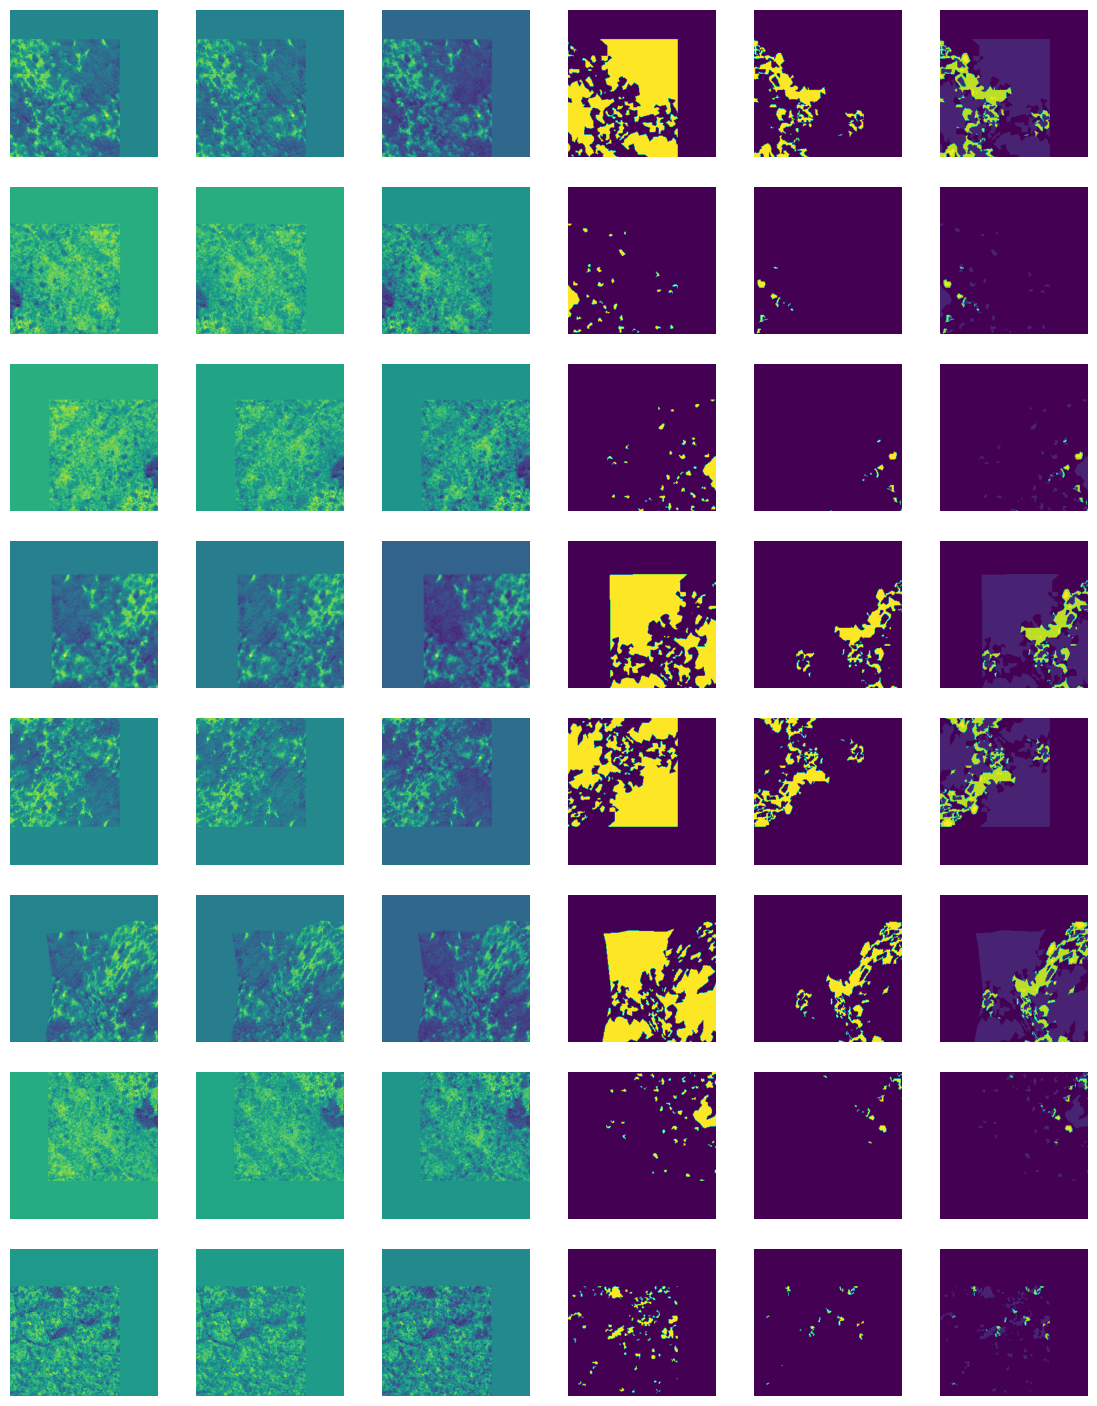

In [5]:
for _ in range(1):
    train_images, real_label = next(train_generator)
    ann = real_label[:,:,:,0]
    wei = real_label[:,:,:,1]
    #overlay of annotation with boundary to check the accuracy
    #6 images in each row are: r, g, b, annotation, weight(boundary), overlay of annotation with weight
    overlay = ann + wei
    overlay = overlay[:,:,:,np.newaxis]
    display_images(np.concatenate((train_images,real_label, overlay), axis = -1))

In [6]:
OPTIMIZER = adaDelta
LOSS = tversky 

#Only for the name of the model in the very end
OPTIMIZER_NAME = 'AdaDelta'
LOSS_NAME = 'weightmap_tversky'

# Declare the path to the final model
# If you want to retrain an exising model then change the cell where model is declared. 
# This path is for storing a model after training.

timestr = time.strftime("%Y%m%d-%H%M")
chf = config.input_image_channel + config.input_label_channel
chs = reduce(lambda a,b: a+str(b), chf, '')


if not os.path.exists(config.model_path):
    os.makedirs(config.model_path)
model_path = os.path.join(config.model_path,'shrubs_{}_{}_{}_{}_{}.h5'.format(timestr,OPTIMIZER_NAME,LOSS_NAME,chs,config.input_shape[0]))

# The weights without the model architecture can also be saved. Just saving the weights is more efficent.

# weight_path="./saved_weights/UNet/{}/".format(timestr)
# if not os.path.exists(weight_path):
#     os.makedirs(weight_path)
# weight_path=weight_path + "{}_weights.best.hdf5".format('UNet_model')
# print(weight_path)

In [7]:
# Define the model and compile it
model = UNet([config.BATCH_SIZE, *config.input_shape],config.input_label_channel)
#model.compile(optimizer=OPTIMIZER, loss=LOSS, metrics=[dice_coef, dice_loss, specificity, sensitivity, accuracy])
model.compile(optimizer="adadelta", loss=LOSS, metrics=[dice_coef, dice_loss, specificity, sensitivity, accuracy])

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input (InputLayer)  │ (None, 256, 256,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ Input[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      2,048 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ batch_normalizat

 Total params: 31,390,465 (119.75 MB)

 Trainable params: 31,384,705 (119.72 MB)

 Non-trainable params: 5,760 (22.50 KB)

In [8]:
# Define callbacks for the early stopping of training, LearningRateScheduler and model checkpointing
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler, EarlyStopping, ReduceLROnPlateau, TensorBoard


checkpoint = ModelCheckpoint(model_path, monitor='val_loss', verbose=1, 
                             save_best_only=True, mode='min', save_weights_only = False)

#reduceonplatea; It can be useful when using adam as optimizer
#Reduce learning rate when a metric has stopped improving (after some patience,reduce by a factor of 0.33, new_lr = lr * factor).
#cooldown: number of epochs to wait before resuming normal operation after lr has been reduced.
reduceLROnPlat = ReduceLROnPlateau(monitor='val_loss', factor=0.33,
                                   patience=4, verbose=1, mode='min',
                                   min_delta=0.0001, cooldown=4, min_lr=1e-16)

#early = EarlyStopping(monitor="val_loss", mode="min", verbose=2, patience=15)

log_dir = os.path.join('./logs','UNet_{}_{}_{}_{}_{}'.format(timestr,OPTIMIZER_NAME,LOSS_NAME,chs, config.input_shape[0]))
#tensorboard = TensorBoard(log_dir=log_dir, histogram_freq=0, write_graph=True, write_grads=False, write_images=False, embeddings_freq=0, embeddings_layer_names=None, embeddings_metadata=None, embeddings_data=None, update_freq='epoch')
tensorboard = TensorBoard(log_dir=log_dir, histogram_freq=0, write_graph=True, update_freq='epoch')

callbacks_list = [checkpoint, tensorboard] #reduceLROnPlat is not required with adaDelta

In [9]:
loss_history = [model.fit(train_generator, 
                         steps_per_epoch=config.MAX_TRAIN_STEPS, 
                         epochs=100,#config.NB_EPOCHS, 
                         validation_data=val_generator,
                         validation_steps=config.VALID_IMG_COUNT,
                         callbacks=callbacks_list,
                         #workers=1,
#                         use_multiprocessing=True # the generator is not very thread safe
                        )]

Epoch 1/100


I0000 00:00:1744985608.011443 4176638 service.cc:152] XLA service 0x149824003760 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1744985608.011484 4176638 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-12GB, Compute Capability 6.0
2025-04-18 10:13:28.570427: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1744985609.881389 4176638 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-04-18 10:13:32.059616: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{} for conv %cudnn-conv-bias-activation.57 = (f32[8,64,256,256]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,3,256,256]{3,2,1,0} %bitcast.12895, f32[64,3,3,3]{3,2,1,0} %bitcast.12902, f32[64]{0} %bitcast.15627), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cud

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.6460 - dice_coef: 0.1088 - dice_loss: 0.8912 - loss: 0.7492 - sensitivity: 0.8671 - specificity: 0.6134

2025-04-18 10:18:22.470535: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{} for conv %cudnn-conv-bias-activation.57 = (f32[8,64,256,256]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,3,256,256]{3,2,1,0} %bitcast.1698, f32[64,3,3,3]{3,2,1,0} %bitcast.1705, f32[64]{0} %bitcast.1707), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="functional_1/conv2d_1/convolution" source_file="/projectnb/modislc/seamorez/.conda/envs/landsat_lsp_env_copy/lib/python3.11/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kRelu","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2025-04-18 10:18:22.777917: I external/local_xla/xla/service/gpu/autotuning/conv_alg


Epoch 1: val_loss improved from inf to 0.64217, saving model to ./saved_models/UNet/shrubs_20250418-1013_AdaDelta_weightmap_tversky_0123_256.h5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 325s 286ms/step - accuracy: 0.6461 - dice_coef: 0.1088 - dice_loss: 0.8912 - loss: 0.7491 - sensitivity: 0.8671 - specificity: 0.6135 - val_accuracy: 0.9089 - val_dice_coef: 0.0704 - val_dice_loss: 0.9296 - val_loss: 0.6422 - val_sensitivity: 0.9222 - val_specificity: 0.9078
Epoch 2/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.9463 - dice_coef: 0.1006 - dice_loss: 0.8994 - loss: 0.3385 - sensitivity: 0.7284 - specificity: 0.9831
Epoch 2: val_loss improved from 0.64217 to 0.55837, saving model to ./saved_models/UNet/shrubs_20250418-1013_AdaDelta_weightmap_tversky_0123_256.h5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 276s 276ms/step - accuracy: 0.9463 - dice_coef: 0.1006 - dice_loss: 0.8994 - loss: 0.3385 - sensitivity: 0.7284 - specificity: 0.9831 - val_accuracy: 0.9334 - val_dice_coef: 0.0675 - val_dice_lo

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.9840 - dice_coef: 0.6601 - dice_loss: 0.3399 - loss: 0.0739 - sensitivity: 0.9010 - specificity: 0.9956
Epoch 86: val_loss did not improve from 0.40976
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 274s 274ms/step - accuracy: 0.9840 - dice_coef: 0.6601 - dice_loss: 0.3399 - loss: 0.0739 - sensitivity: 0.9010 - specificity: 0.9956 - val_accuracy: 0.9522 - val_dice_coef: 0.5879 - val_dice_loss: 0.4121 - val_loss: 0.4248 - val_sensitivity: 0.8175 - val_specificity: 0.9634
Epoch 87/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.9839 - dice_coef: 0.6647 - dice_loss: 0.3353 - loss: 0.0719 - sensitivity: 0.9036 - specificity: 0.9955
Epoch 87: val_loss did not improve from 0.40976
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 274s 274ms/step - accuracy: 0.9839 - dice_coef: 0.6647 - dice_loss: 0.3353 - loss: 0.0719 - sensitivity: 0.9036 - specificity: 0.9955 - val_accuracy: 0.9515 - val_dice_coef: 0.5973 - val_dice_loss: 0.4027 - val_loss: 0.4278 - v

In [10]:
# Load model after training
# If you load a model with different python version, than you may run into a problem: https://github.com/keras-team/keras/issues/9595#issue-303471777

model = load_model(model_path, custom_objects={'tversky': LOSS, 'dice_coef': dice_coef, 'dice_loss':dice_loss, 'accuracy':accuracy , 'specificity': specificity, 'sensitivity':sensitivity}, compile=False)

# In case you want to use multiple GPU you can uncomment the following lines.
# from tensorflow.python.keras.utils import multi_gpu_model
# model = multi_gpu_model(model, gpus=2, cpu_merge=False)

#model.compile(optimizer=OPTIMIZER, loss=LOSS, metrics=[dice_coef, dice_loss, accuracy, specificity, sensitivity])
model.compile(optimizer="adadelta", loss=LOSS, metrics=[dice_coef, dice_loss, accuracy, specificity, sensitivity])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


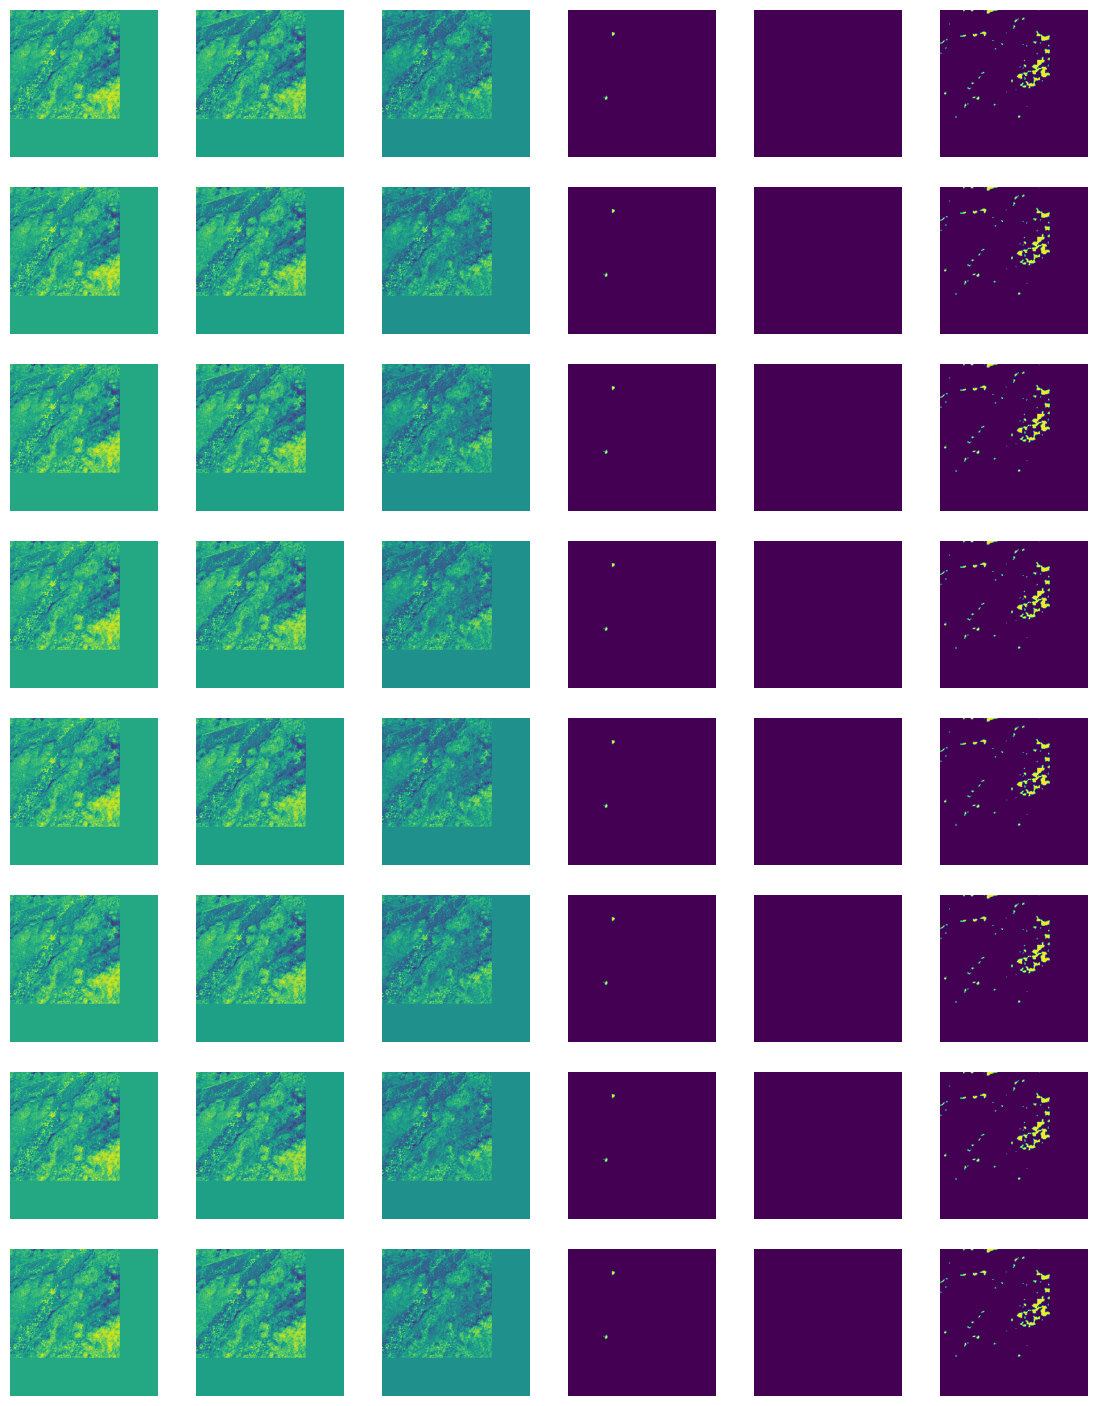

In [11]:
# Print one batch on the training/test data!
for i in range(1):
    test_images, real_label = next(test_generator)
    #6 images per row: r, g, b, label, weight, prediction
    prediction = model.predict(test_images, steps=1)
    prediction[prediction>0.5]=1
    prediction[prediction<=0.5]=0
    display_images(np.concatenate((test_images, real_label, prediction), axis = -1))